In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [23]:
# Load data
data_dir = Path('/home/niclasflehmig/VisualCodeProjects/H2-dispersion-model/data')
df = pd.read_csv(data_dir / 'unified_raw.csv')

In [24]:
df.describe()

,time,h2_volume_fraction,mass_flow,sensor_id,x,y,z
count,257490.000000,2.574900e+05,257490.000000,257490.000000,257490.000000,257490.000000,257490.000000
mean,91.795805,4.582533e-02,0.386553,15.484737,0.460611,2.170033,0.485587
std,56.397255,5.304366e-02,0.334094,8.786659,0.200737,1.611569,0.312804
min,0.000000,1.000000e-08,0.029177,1.000000,0.000000,0.000000,0.000000
25%,43.640000,1.770129e-03,0.091000,8.000000,0.460000,0.260000,0.270000
50%,87.887864,1.940291e-02,0.434385,15.000000,0.470000,2.220000,0.520000
75%,137.720000,8.445952e-02,0.484407,23.000000,0.470000,3.540000,0.800000
max,199.990000,3.082763e-01,1.270000,30.000000,0.900000,4.680000,0.800000


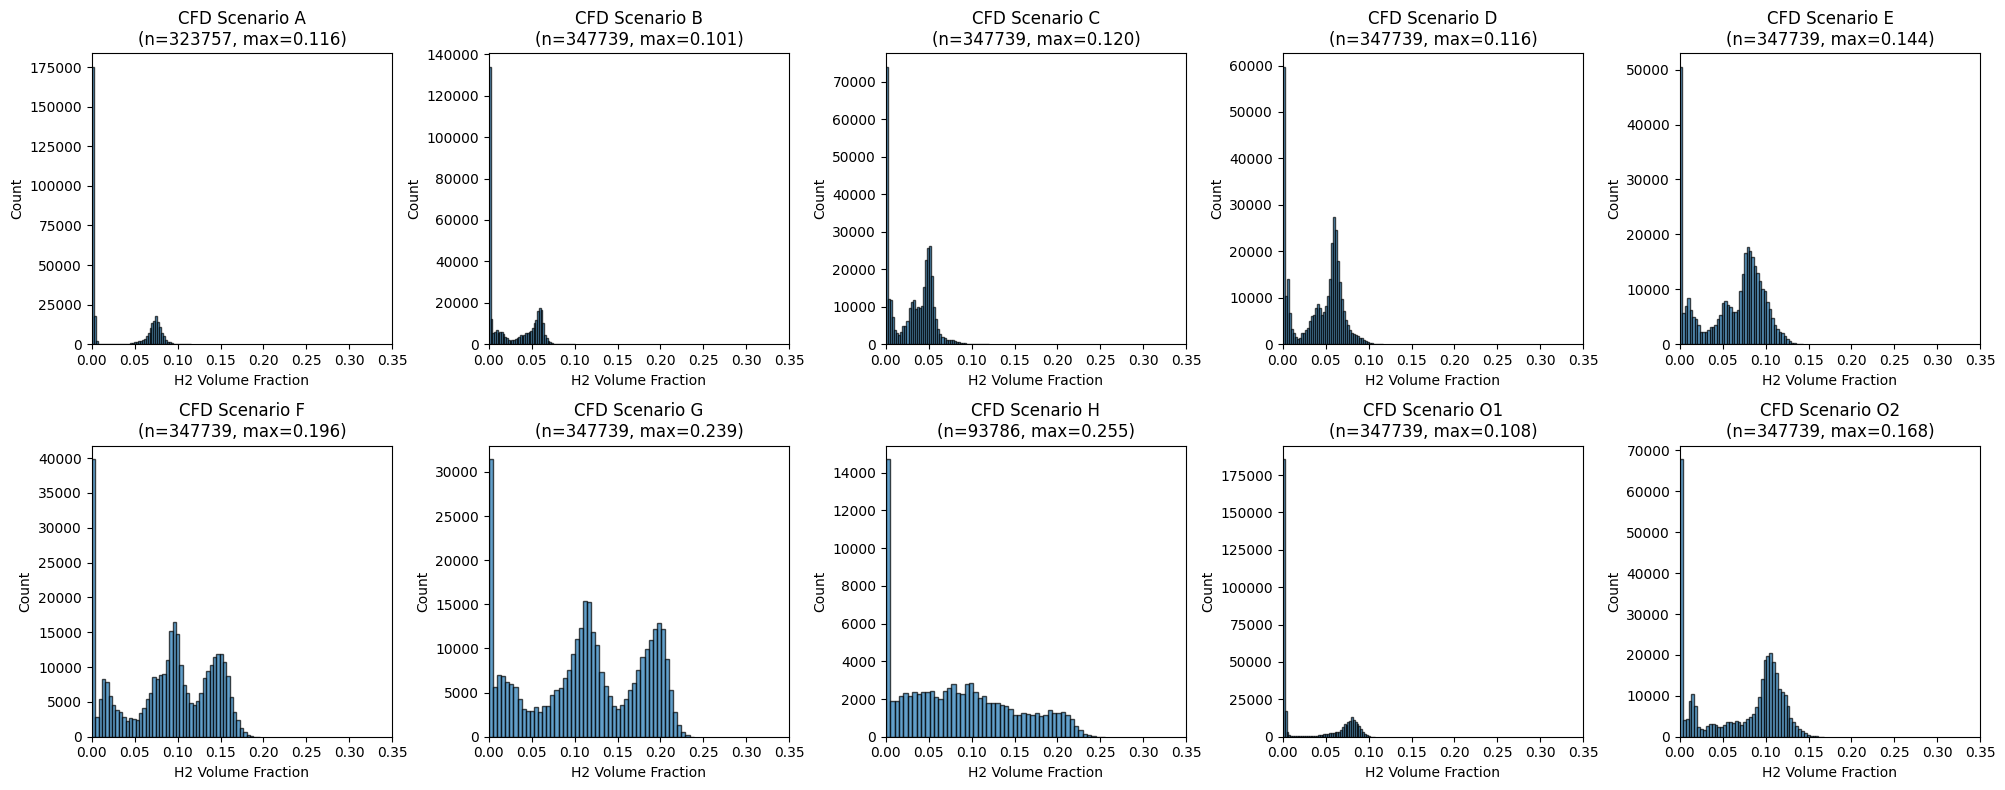

In [14]:
# CFD scenario histograms
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

cfd_scenarios = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'O1', 'O2']

for idx, scenario in enumerate(cfd_scenarios):
    ax = axes[idx]
    df_scenario = df[(df['source'] == 'cfd') & (df['scenario'] == scenario)]
    
    ax.hist(df_scenario['h2_volume_fraction'], bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(f'CFD Scenario {scenario}\n(n={len(df_scenario)}, max={df_scenario["h2_volume_fraction"].max():.3f})')
    ax.set_xlabel('H2 Volume Fraction')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 0.35)

plt.tight_layout()
plt.savefig(data_dir / 'cfd_histograms.png', dpi=150)
plt.show()

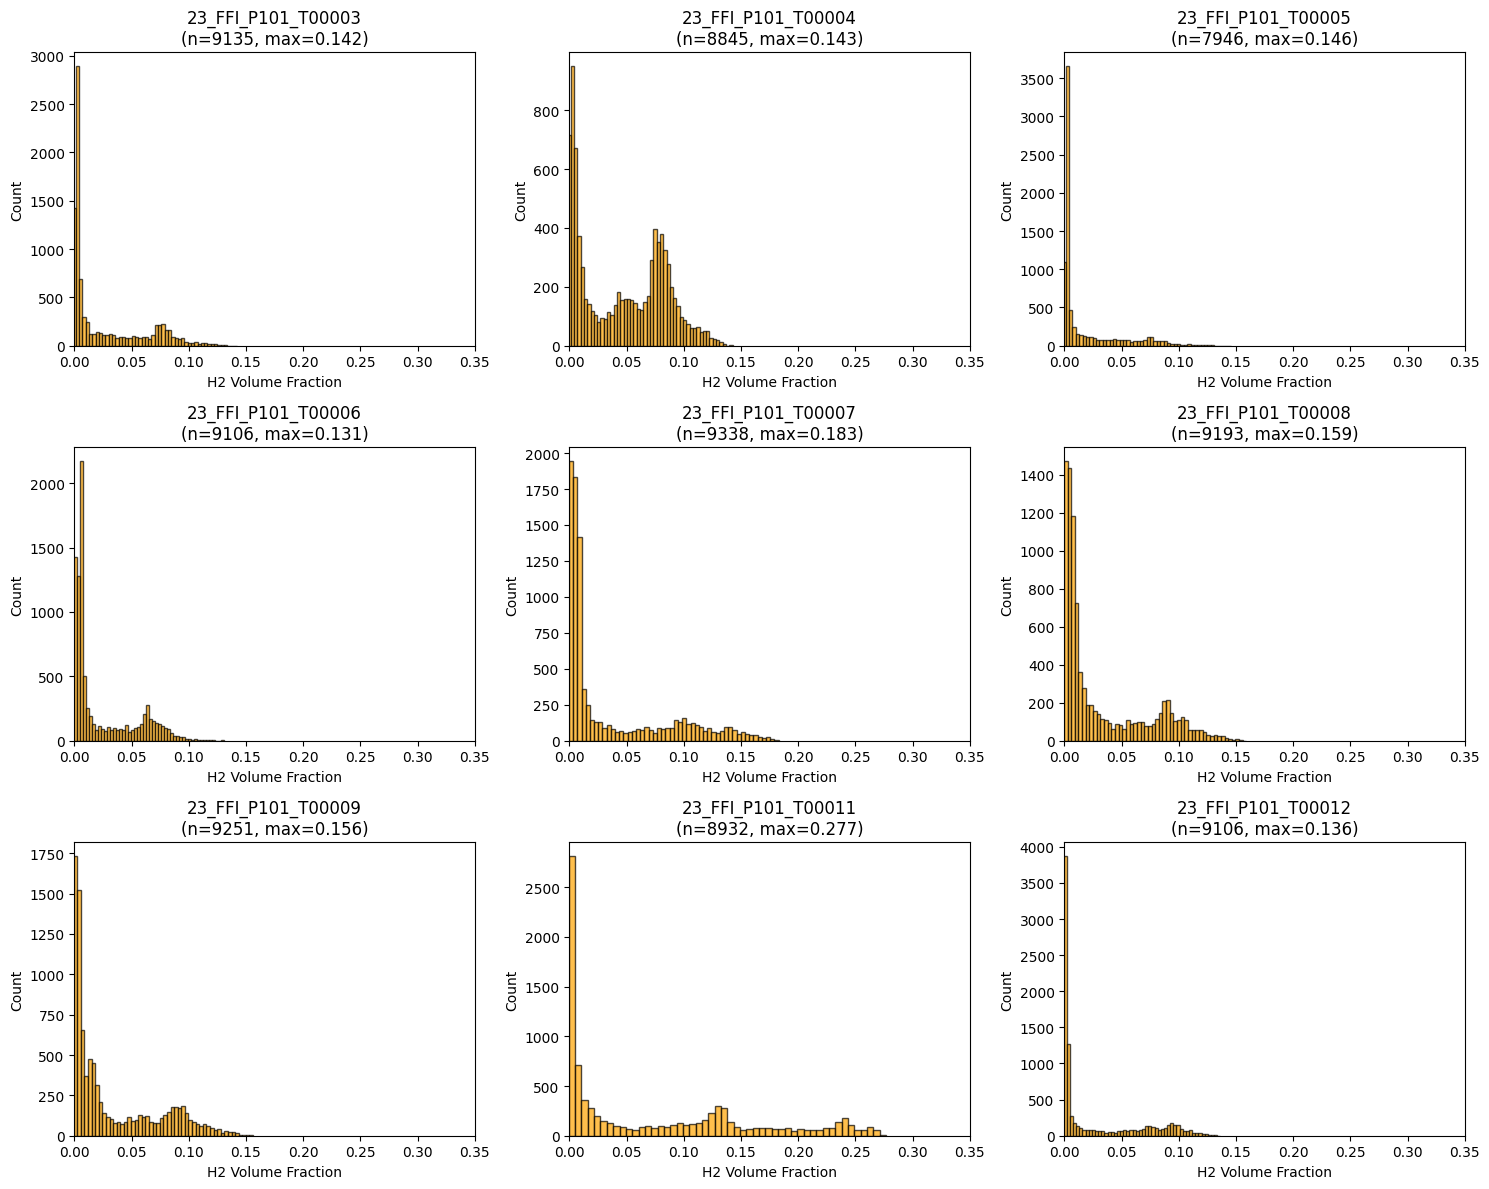

In [15]:
# Experiment histograms (sample of 9)
exp_ids = df[df['source'] == 'experiment']['experiment_id'].unique()[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, exp_id in enumerate(exp_ids):
    ax = axes[idx]
    df_exp = df[df['experiment_id'] == exp_id]
    
    ax.hist(df_exp['h2_volume_fraction'], bins=50, alpha=0.7, edgecolor='black', color='orange')
    ax.set_title(f'{exp_id}\n(n={len(df_exp)}, max={df_exp["h2_volume_fraction"].max():.3f})')
    ax.set_xlabel('H2 Volume Fraction')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 0.35)

plt.tight_layout()
plt.savefig(data_dir / 'experiment_histograms.png', dpi=150)
plt.show()

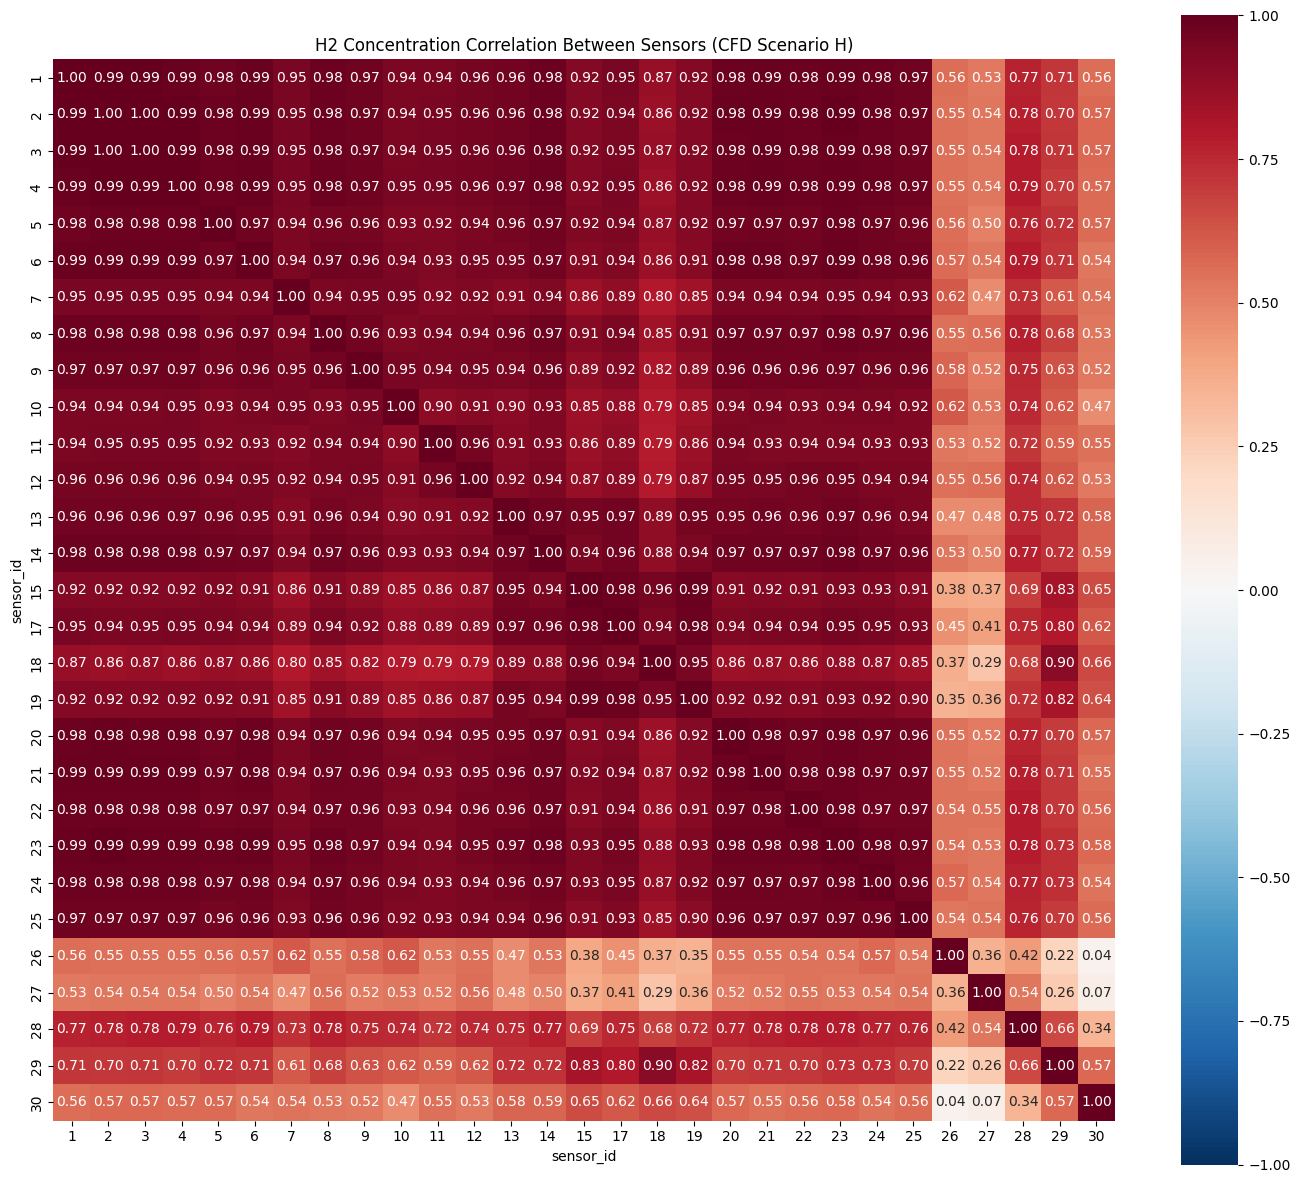

In [31]:
# Create pivot table: sensors vs time
# Sample one CFD scenario for correlation
df_cfd_sample = df[(df['source'] == 'cfd') & (df['scenario'] == 'H')]

# Pivot to get sensors as columns
pivot = df_cfd_sample.pivot_table(
    index='time', 
    columns='sensor_id', 
    values='h2_volume_fraction', 
    aggfunc='mean'
)

# Calculate correlation
corr = pivot.corr()

# Plot
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('H2 Concentration Correlation Between Sensors (CFD Scenario H)')
plt.tight_layout()
plt.savefig(data_dir / 'sensor_correlation_cfd_H.png', dpi=150)
plt.show()

In [6]:
from scipy import signal

def resample_data(df, original_freq=100, target_freq=1.6):
    num_samples = int(len(df) * target_freq / original_freq)
    resampled_data = signal.resample(df['h2_volume_fraction'].values, num_samples)
    new_time = np.linspace(df['time'].iloc[0], df['time'].iloc[-1], num_samples)
    resampled_data[0] = 0
    df_resampled = pd.DataFrame({'time': new_time, 'h2_volume_fraction_resampled': resampled_data})
    df_other = df.drop(columns=['h2_volume_fraction']) 
    return pd.merge_asof(
        df_resampled.sort_values('time'),
        df_other.sort_values('time'),
        on='time',
        direction='nearest'
    )

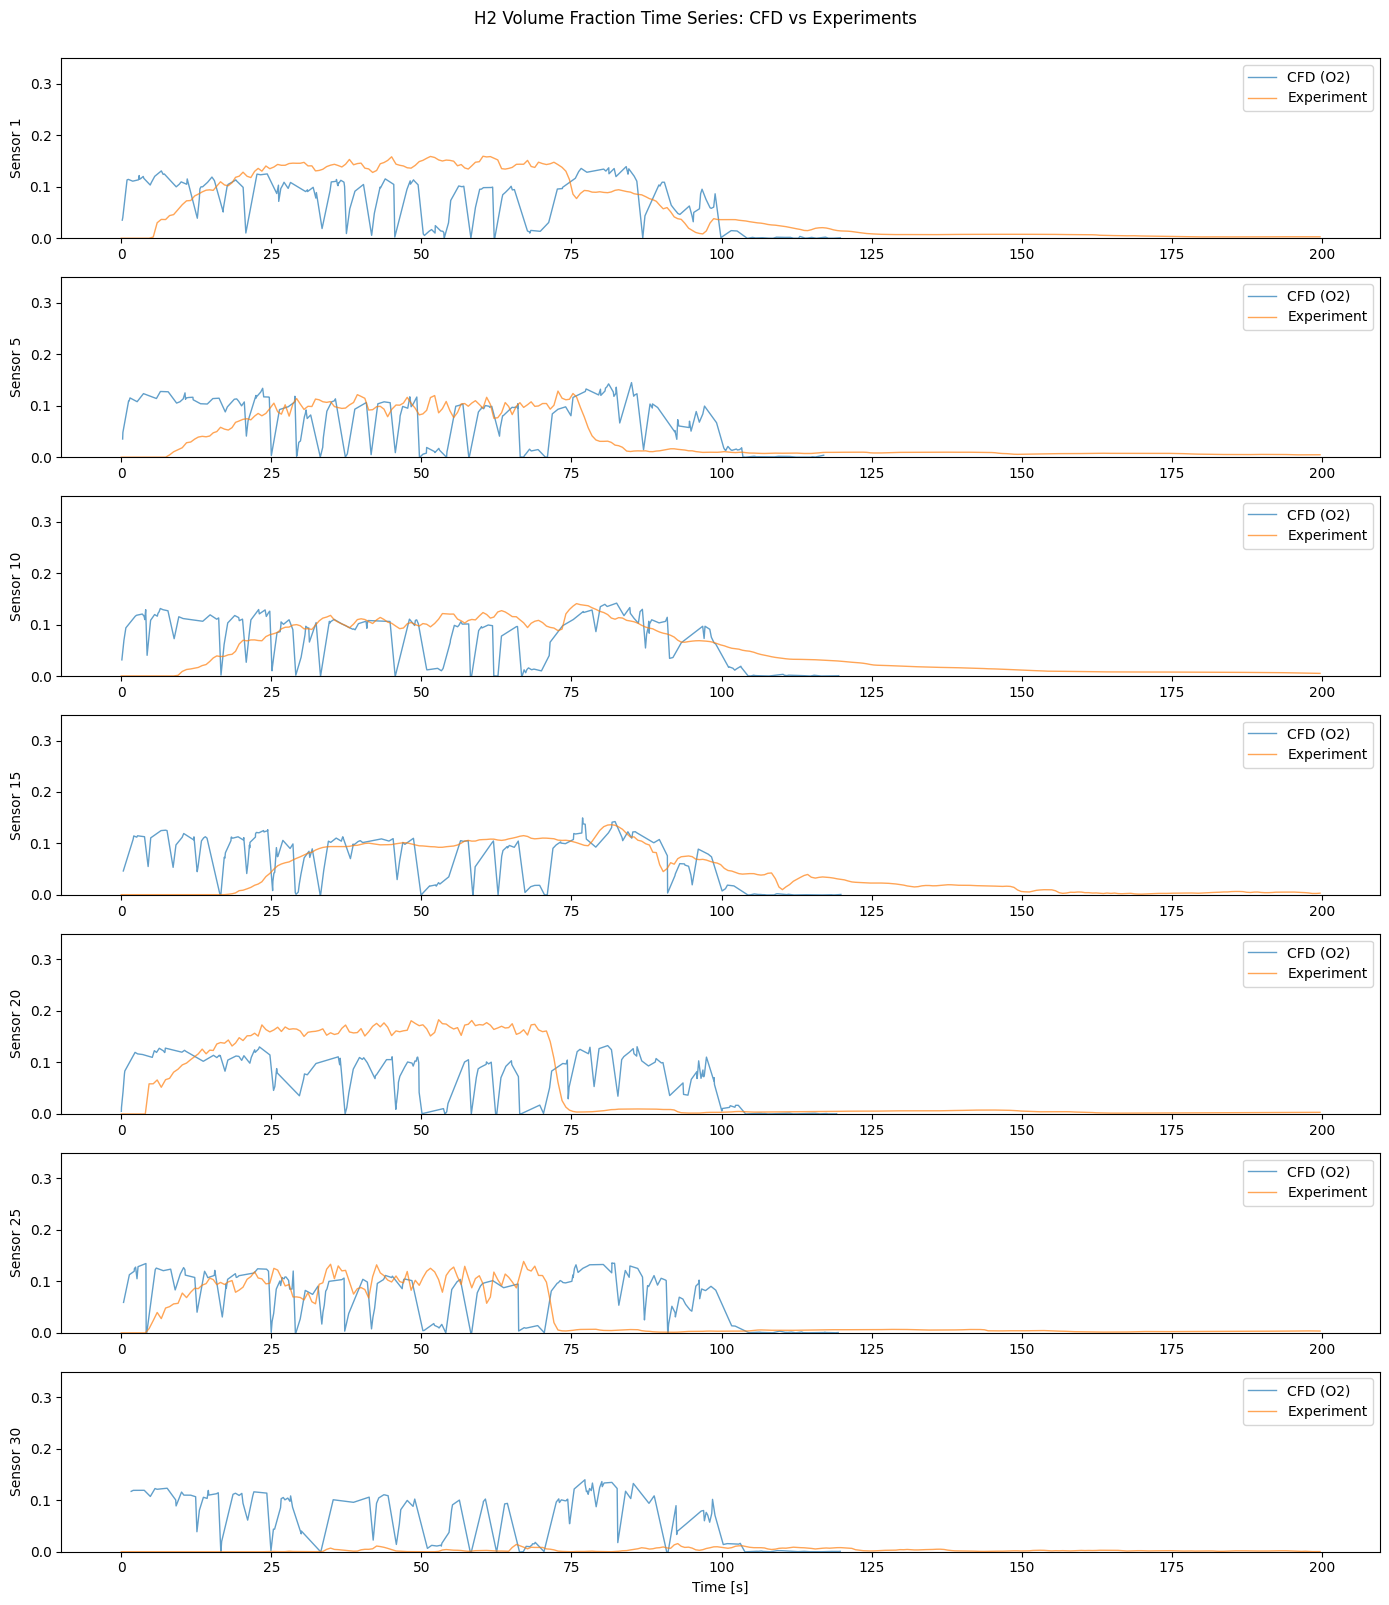

In [16]:
# Plot time series for a few sensors
sensor_ids = [1, 5, 10, 15, 20, 25, 30]
fig, axes = plt.subplots(len(sensor_ids), 1, figsize=(14, 16))

for idx, sensor_id in enumerate(sensor_ids):
    ax = axes[idx]
    
    # CFD data
    df_cfd_sensor = df[(df['source'] == 'cfd') & (df['scenario'] == 'O2') & 
                       (df['sensor_id'] == sensor_id)]
    if len(df_cfd_sensor) > 0:
        ax.plot(df_cfd_sensor['time'], df_cfd_sensor['h2_volume_fraction'], 
                label='CFD (O2)', alpha=0.7, linewidth=1)
    
    # Experimental data (reality gap)
    df_exp_sensor = df[(df['experiment_id'] == '23_FFI_P101_T00007') &
                       (df['sensor_id'] == sensor_id)]
    if len(df_exp_sensor) > 0:
        ax.plot(df_exp_sensor['time'], df_exp_sensor['h2_volume_fraction'], 
                label='Experiment', alpha=0.7, linewidth=1)
    
    ax.set_ylabel(f'Sensor {int(sensor_id)}')
    ax.legend()
    ax.set_ylim(0, 0.35)

axes[-1].set_xlabel('Time [s]')
plt.suptitle('H2 Volume Fraction Time Series: CFD vs Experiments', y=1.0)
plt.tight_layout()
plt.savefig(data_dir / 'time_series_comparison_scenario_O2.png', dpi=150)
plt.show()

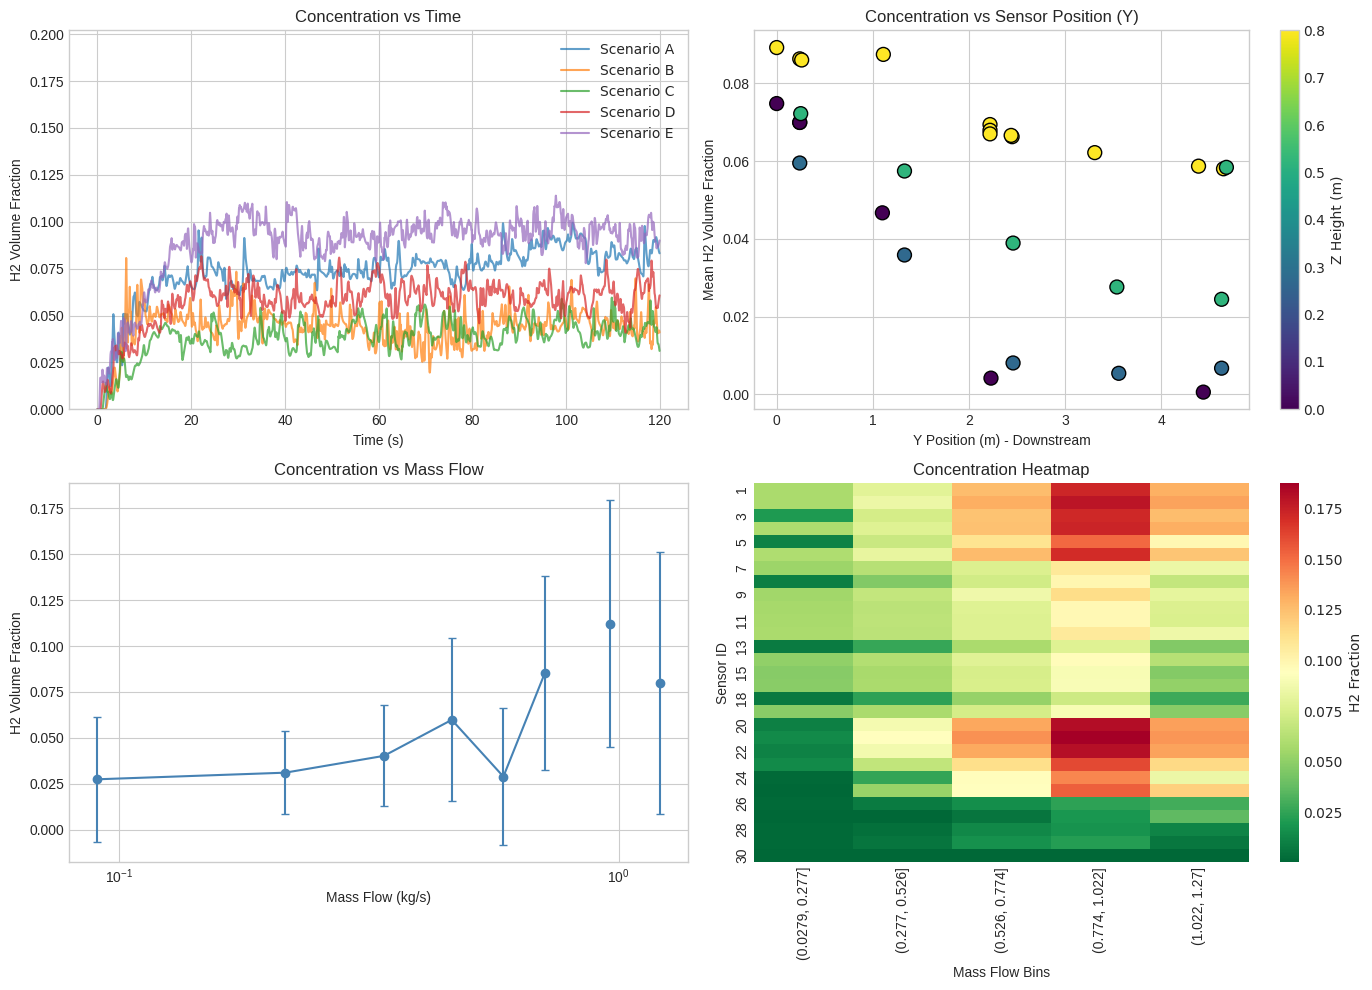


=== DATA SUMMARY ===
Total records: 3,541,394
Scenarios: 33
Sensors: 29
Time range: [0.0, 462.8] s
Mass flow range: [0.029, 1.270] kg/s
H2 concentration range: [-0.0018, 0.3083]


In [57]:
# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Fix font for H2 subscript
plt.rcParams['font.family'] = 'DejaVu Sans'
# 1. Concentration over Time
ax1 = axes[0, 0]
for scenario in df['scenario'].unique()[:5]:  # Plot first 5 scenarios
    df_scen = df[df['scenario'] == scenario]
    # Sample one sensor per scenario
    sensor = df_scen['sensor_id'].iloc[0]
    df_sensor = df_scen[df_scen['sensor_id'] == sensor]
    ax1.plot(df_sensor['time'], df_sensor['h2_volume_fraction'], 
             label=f'Scenario {scenario}', alpha=0.7)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('H2 Volume Fraction')  # Fixed: no subscript
ax1.set_title('Concentration vs Time')
ax1.legend()
ax1.set_ylim(0, df['h2_volume_fraction'].quantile(0.99))
# 2. Concentration over Sensor Positions (Y-axis, downstream)
ax2 = axes[0, 1]
# Get unique sensor positions
sensor_pos = df[['sensor_id', 'x', 'y', 'z']].drop_duplicates().set_index('sensor_id')
# Average concentration per sensor across all scenarios/times
sensor_conc = df.groupby('sensor_id')['h2_volume_fraction'].mean()
sensor_pos['conc'] = sensor_conc
scatter = ax2.scatter(sensor_pos['y'], sensor_pos['conc'], 
                     c=sensor_pos['z'], cmap='viridis', s=100, edgecolors='black')
ax2.set_xlabel('Y Position (m) - Downstream')
ax2.set_ylabel('Mean H2 Volume Fraction')  # Fixed: no subscript
ax2.set_title('Concentration vs Sensor Position (Y)')
plt.colorbar(scatter, ax=ax2, label='Z Height (m)')
# 3. Concentration over Mass Flow
ax3 = axes[1, 0]
# Bin mass flow for cleaner visualization
df['mass_flow_bin'] = pd.cut(df['mass_flow'], bins=10)
massflow_conc = df.groupby('mass_flow_bin', observed=False)['h2_volume_fraction'].agg(['mean', 'std'])
massflow_centers = [interval.mid for interval in massflow_conc.index]
ax3.errorbar(massflow_centers, massflow_conc['mean'], yerr=massflow_conc['std'],
            fmt='o-', capsize=3, color='steelblue')
ax3.set_xlabel('Mass Flow (kg/s)')
ax3.set_ylabel('H2 Volume Fraction')  # Fixed: no subscript
ax3.set_title('Concentration vs Mass Flow')
ax3.set_xscale('log')
# 4. Heatmap: Concentration by Sensor and Mass Flow
ax4 = axes[1, 1]
pivot_data = df.pivot_table(
    values='h2_volume_fraction',
    index='sensor_id',
    columns=pd.cut(df['mass_flow'], bins=5),
    aggfunc='mean',
    observed=False
)
sns.heatmap(pivot_data, cmap='RdYlGn_r', ax=ax4, cbar_kws={'label': 'H2 Fraction'})
ax4.set_xlabel('Mass Flow Bins')
ax4.set_ylabel('Sensor ID')
ax4.set_title('Concentration Heatmap')
plt.tight_layout()
plt.savefig('data_analysis_overview.png', dpi=150, bbox_inches='tight')
plt.show()
# Summary statistics
print("\n=== DATA SUMMARY ===")
print(f"Total records: {len(df):,}")
print(f"Scenarios: {df['scenario'].nunique()}")
print(f"Sensors: {df['sensor_id'].nunique()}")
print(f"Time range: [{df['time'].min():.1f}, {df['time'].max():.1f}] s")
print(f"Mass flow range: [{df['mass_flow'].min():.3f}, {df['mass_flow'].max():.3f}] kg/s")
print(f"H2 concentration range: [{df['h2_volume_fraction'].min():.4f}, {df['h2_volume_fraction'].max():.4f}]")

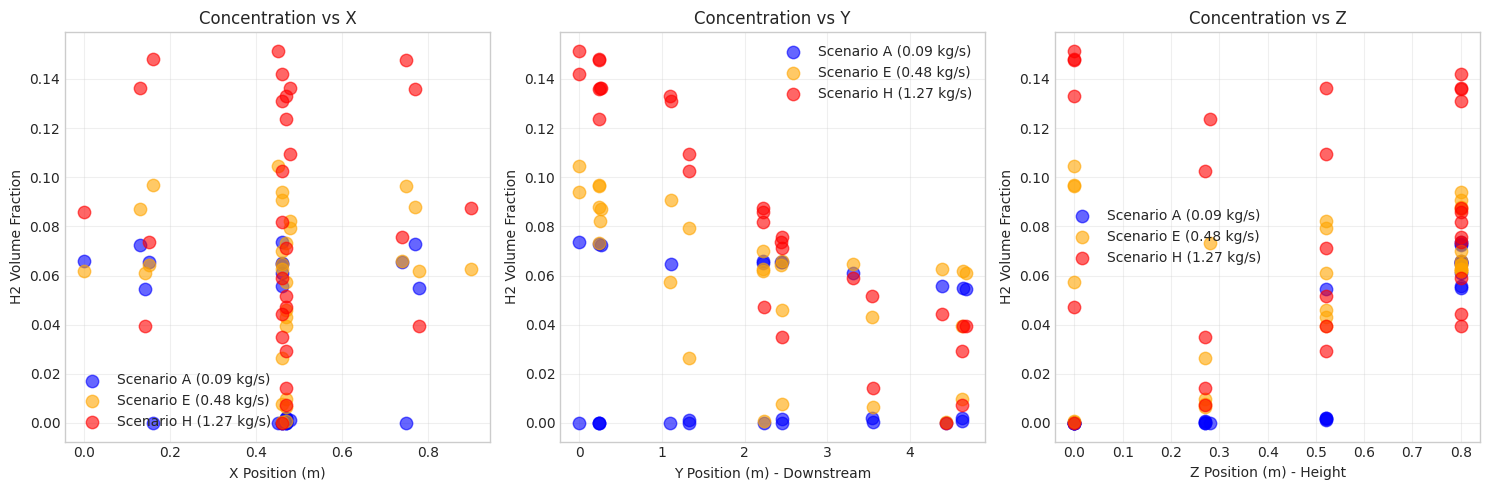

In [59]:
# Select 3 representative scenarios (e.g., A, E, H - different mass flows)
selected_scenarios = ['A', 'E', 'H']
colors = {'A': 'blue', 'E': 'orange', 'H': 'red'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for scenario in selected_scenarios:
    df_scen = df[df['scenario'] == scenario]
    
    # Average concentration per sensor for this scenario
    sensor_conc = df_scen.groupby('sensor_id')['h2_volume_fraction'].mean()
    sensor_pos = df_scen[['sensor_id', 'x', 'y', 'z']].drop_duplicates().set_index('sensor_id')
    sensor_pos['conc'] = sensor_conc
    
    mass_flow = df_scen['mass_flow'].iloc[0]
    label = f'Scenario {scenario} ({mass_flow:.2f} kg/s)'
    
    # X position
    axes[0].scatter(sensor_pos['x'], sensor_pos['conc'], 
                   c=colors[scenario], s=80, alpha=0.6, label=label)
    
    # Y position
    axes[1].scatter(sensor_pos['y'], sensor_pos['conc'], 
                   c=colors[scenario], s=80, alpha=0.6, label=label)
    
    # Z position
    axes[2].scatter(sensor_pos['z'], sensor_pos['conc'], 
                   c=colors[scenario], s=80, alpha=0.6, label=label)

# Formatting
axes[0].set_xlabel('X Position (m)')
axes[0].set_ylabel('H2 Volume Fraction')
axes[0].set_title('Concentration vs X')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Y Position (m) - Downstream')
axes[1].set_ylabel('H2 Volume Fraction')
axes[1].set_title('Concentration vs Y')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Z Position (m) - Height')
axes[2].set_ylabel('H2 Volume Fraction')
axes[2].set_title('Concentration vs Z')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('concentration_vs_position_3scenarios.png', dpi=150)
plt.show()


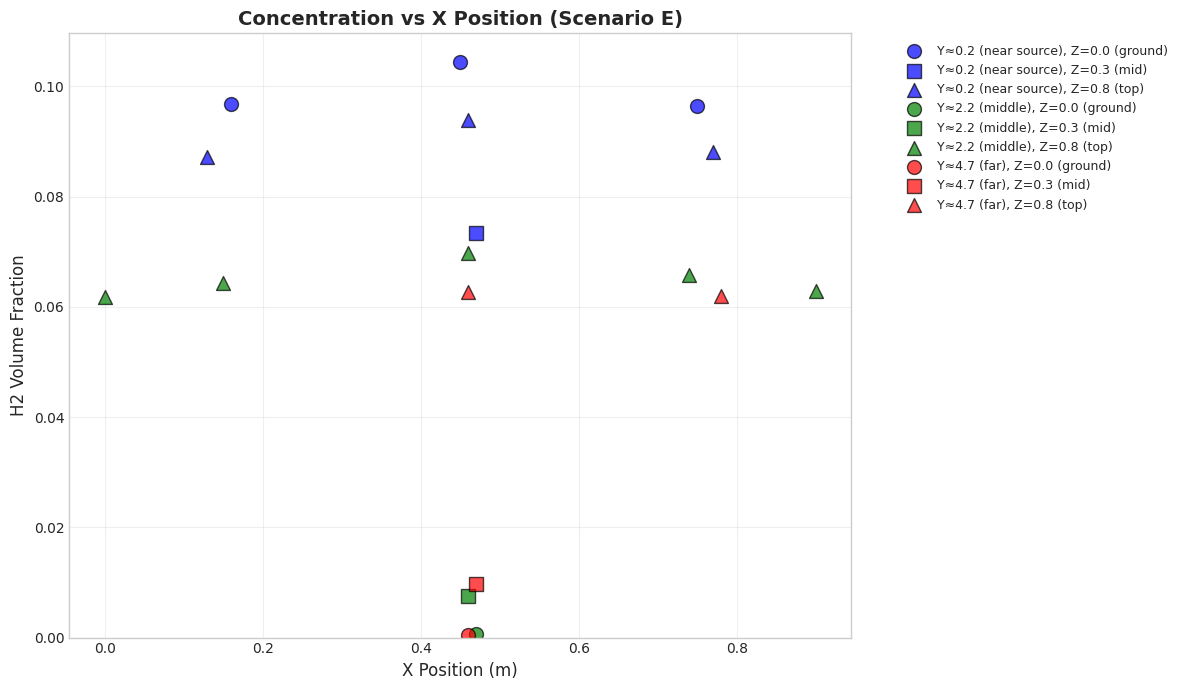

In [60]:
# Select one representative scenario
scenario = 'E'  # Medium mass flow
df_scen = df[df['scenario'] == scenario]

# Define Y and Z slices
y_values = [0.24, 2.22, 4.65]  # Close to start, middle, end
z_values = [0.0, 0.27, 0.8]    # Low, middle, top
y_labels = ['Y≈0.2 (near source)', 'Y≈2.2 (middle)', 'Y≈4.7 (far)']
z_labels = ['Z=0.0 (ground)', 'Z=0.3 (mid)', 'Z=0.8 (top)']

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['blue', 'green', 'red']
markers = ['o', 's', '^']

for i, (y, y_label) in enumerate(zip(y_values, y_labels)):
    for j, (z, z_label) in enumerate(zip(z_values, z_labels)):
        # Find sensors close to this (y, z) combination
        tol_y = 0.3
        tol_z = 0.15
        
        mask = (np.abs(df_scen['y'] - y) < tol_y) & (np.abs(df_scen['z'] - z) < tol_z)
        df_slice = df_scen[mask]
        
        if len(df_slice) > 0:
            # Average concentration by x position
            x_conc = df_slice.groupby('x')['h2_volume_fraction'].mean()
            
            label = f'{y_label}, {z_label}'
            ax.scatter(x_conc.index, x_conc.values, 
                      c=colors[i], marker=markers[j], s=100, 
                      alpha=0.7, edgecolors='black', label=label)

ax.set_xlabel('X Position (m)', fontsize=12)
ax.set_ylabel('H2 Volume Fraction', fontsize=12)
ax.set_title(f'Concentration vs X Position (Scenario {scenario})', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig('concentration_vs_x_slices.png', dpi=150, bbox_inches='tight')
plt.show()

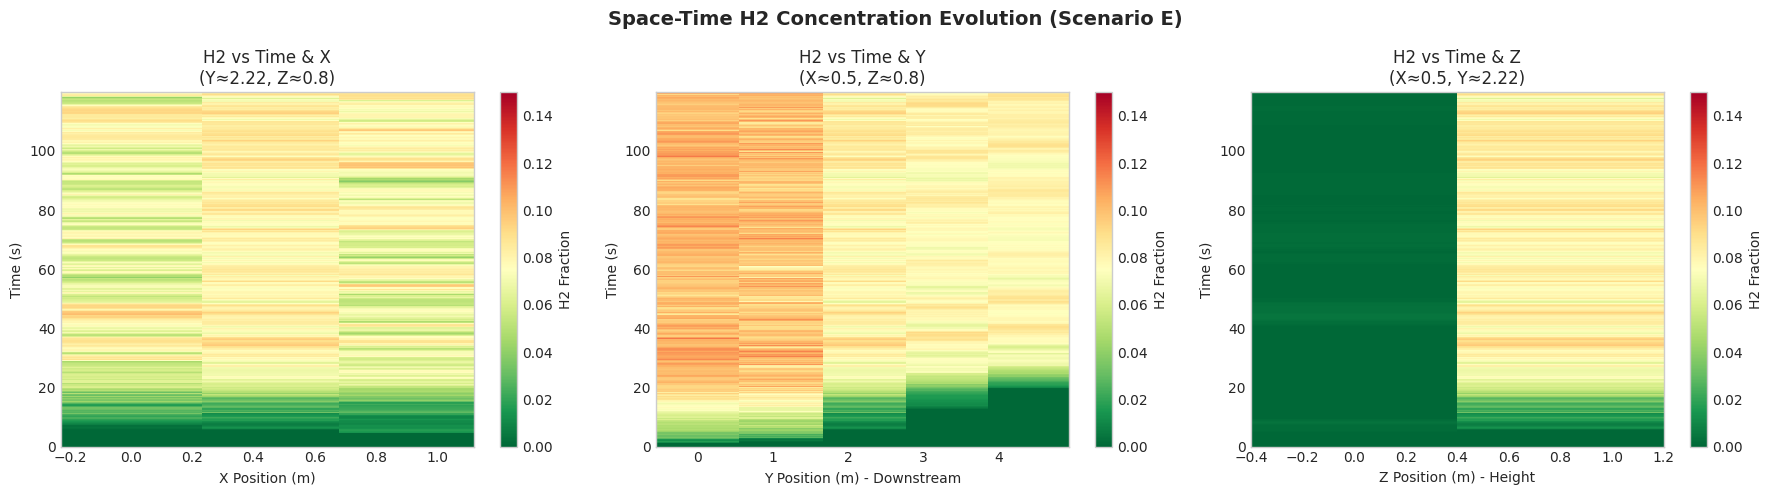

In [61]:
# Select representative scenario
scenario = 'E'
df_scen = df[df['scenario'] == scenario]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. H2 over Time and X (fix Y≈2.2, Z≈0.8 - center height)
ax1 = axes[0]
y_fix, z_fix = 2.22, 0.8
tol = 0.2

df_tx = df_scen[
    (np.abs(df_scen['y'] - y_fix) < tol) & 
    (np.abs(df_scen['z'] - z_fix) < tol)
]

if len(df_tx) > 0:
    pivot_tx = df_tx.pivot_table(
        values='h2_volume_fraction',
        index='time',
        columns='x',
        aggfunc='mean'
    )
    im1 = ax1.pcolormesh(pivot_tx.columns, pivot_tx.index, pivot_tx.values,
                        cmap='RdYlGn_r', shading='auto', vmin=0, vmax=0.15)
    ax1.set_xlabel('X Position (m)')
    ax1.set_ylabel('Time (s)')
    ax1.set_title(f'H2 vs Time & X\n(Y≈{y_fix}, Z≈{z_fix})')
    plt.colorbar(im1, ax=ax1, label='H2 Fraction')

# 2. H2 over Time and Y (fix X≈0.5, Z≈0.8)
ax2 = axes[1]
x_fix, z_fix = 0.5, 0.8

df_ty = df_scen[
    (np.abs(df_scen['x'] - x_fix) < tol) & 
    (np.abs(df_scen['z'] - z_fix) < tol)
]

if len(df_ty) > 0:
    pivot_ty = df_ty.pivot_table(
        values='h2_volume_fraction',
        index='time',
        columns='y',
        aggfunc='mean'
    )
    im2 = ax2.pcolormesh(pivot_ty.columns, pivot_ty.index, pivot_ty.values,
                        cmap='RdYlGn_r', shading='auto', vmin=0, vmax=0.15)
    ax2.set_xlabel('Y Position (m) - Downstream')
    ax2.set_ylabel('Time (s)')
    ax2.set_title(f'H2 vs Time & Y\n(X≈{x_fix}, Z≈{z_fix})')
    plt.colorbar(im2, ax=ax2, label='H2 Fraction')

# 3. H2 over Time and Z (fix X≈0.5, Y≈2.2)
ax3 = axes[2]
x_fix, y_fix = 0.5, 2.22

df_tz = df_scen[
    (np.abs(df_scen['x'] - x_fix) < tol) & 
    (np.abs(df_scen['y'] - y_fix) < tol)
]

if len(df_tz) > 0:
    pivot_tz = df_tz.pivot_table(
        values='h2_volume_fraction',
        index='time',
        columns='z',
        aggfunc='mean'
    )
    im3 = ax3.pcolormesh(pivot_tz.columns, pivot_tz.index, pivot_tz.values,
                        cmap='RdYlGn_r', shading='auto', vmin=0, vmax=0.15)
    ax3.set_xlabel('Z Position (m) - Height')
    ax3.set_ylabel('Time (s)')
    ax3.set_title(f'H2 vs Time & Z\n(X≈{x_fix}, Y≈{y_fix})')
    plt.colorbar(im3, ax=ax3, label='H2 Fraction')

plt.suptitle(f'Space-Time H2 Concentration Evolution (Scenario {scenario})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('h2_spacetime_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

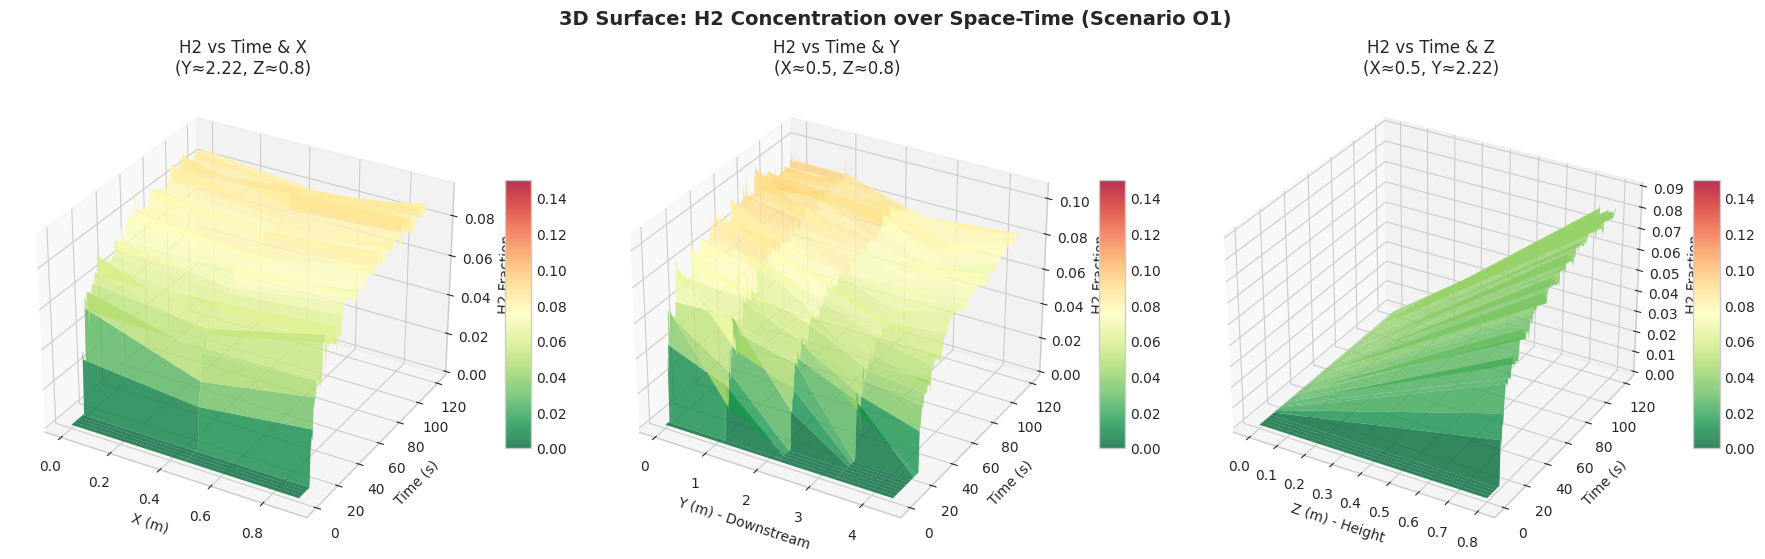

In [65]:
# Select scenario
scenario = 'O1'
df_scen = df[df['scenario'] == scenario]

fig = plt.figure(figsize=(18, 6))

# 1. H2 surface over Time and X
ax1 = fig.add_subplot(131, projection='3d')
y_fix, z_fix = 2.22, 0.8
tol = 0.2

df_tx = df_scen[
    (np.abs(df_scen['y'] - y_fix) < tol) & 
    (np.abs(df_scen['z'] - z_fix) < tol)
]

if len(df_tx) > 0:
    pivot = df_tx.pivot_table(values='h2_volume_fraction', index='time', columns='x', aggfunc='mean')
    X, T = np.meshgrid(pivot.columns.values, pivot.index.values)
    Z = pivot.values
    
    surf1 = ax1.plot_surface(X, T, Z, cmap='RdYlGn_r', alpha=0.8, 
                            vmin=0, vmax=0.15, edgecolor='none')
    ax1.set_xlabel('X (m)')
    ax1.set_ylabel('Time (s)')
    ax1.set_zlabel('H2 Fraction')
    ax1.set_title(f'H2 vs Time & X\n(Y≈{y_fix}, Z≈{z_fix})')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# 2. H2 surface over Time and Y
ax2 = fig.add_subplot(132, projection='3d')
x_fix, z_fix = 0.5, 0.8

df_ty = df_scen[
    (np.abs(df_scen['x'] - x_fix) < tol) & 
    (np.abs(df_scen['z'] - z_fix) < tol)
]

if len(df_ty) > 0:
    pivot = df_ty.pivot_table(values='h2_volume_fraction', index='time', columns='y', aggfunc='mean')
    Y, T = np.meshgrid(pivot.columns.values, pivot.index.values)
    Z = pivot.values
    
    surf2 = ax2.plot_surface(Y, T, Z, cmap='RdYlGn_r', alpha=0.8,
                            vmin=0, vmax=0.15, edgecolor='none')
    ax2.set_xlabel('Y (m) - Downstream')
    ax2.set_ylabel('Time (s)')
    ax2.set_zlabel('H2 Fraction')
    ax2.set_title(f'H2 vs Time & Y\n(X≈{x_fix}, Z≈{z_fix})')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

# 3. H2 surface over Time and Z
ax3 = fig.add_subplot(133, projection='3d')
x_fix, y_fix = 0.5, 2.22

df_tz = df_scen[
    (np.abs(df_scen['x'] - x_fix) < tol) & 
    (np.abs(df_scen['y'] - y_fix) < tol)
]

if len(df_tz) > 0:
    pivot = df_tz.pivot_table(values='h2_volume_fraction', index='time', columns='z', aggfunc='mean')
    Z_pos, T = np.meshgrid(pivot.columns.values, pivot.index.values)
    H2 = pivot.values
    
    surf3 = ax3.plot_surface(Z_pos, T, H2, cmap='RdYlGn_r', alpha=0.8,
                            vmin=0, vmax=0.15, edgecolor='none')
    ax3.set_xlabel('Z (m) - Height')
    ax3.set_ylabel('Time (s)')
    ax3.set_zlabel('H2 Fraction')
    ax3.set_title(f'H2 vs Time & Z\n(X≈{x_fix}, Y≈{y_fix})')
    fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)

plt.suptitle(f'3D Surface: H2 Concentration over Space-Time (Scenario {scenario})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('h2_spacetime_3d_surface.png', dpi=150, bbox_inches='tight')
plt.show()


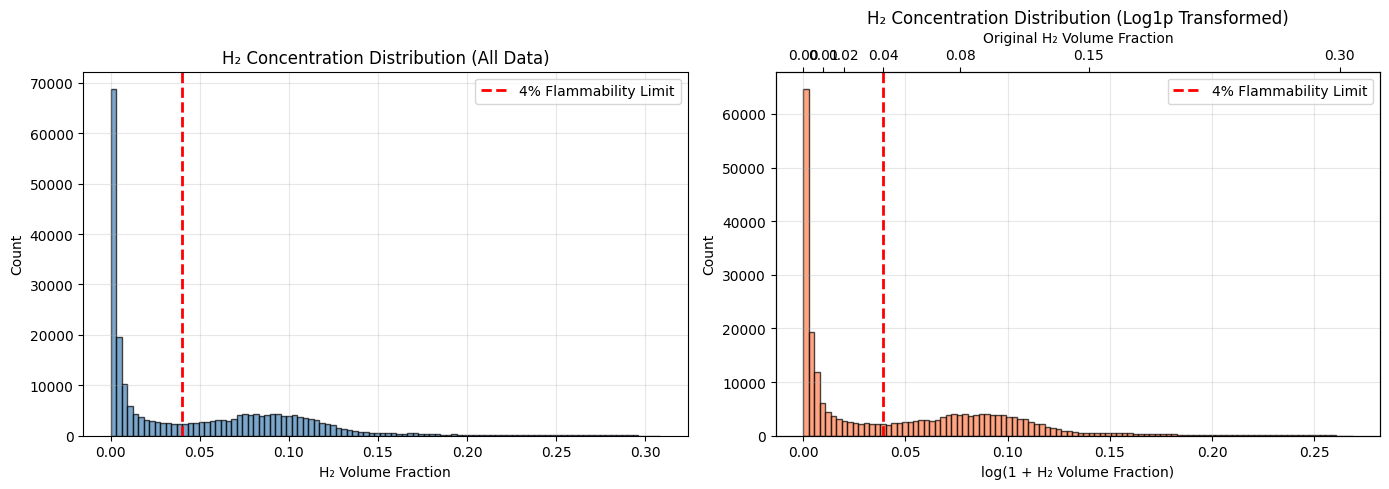

Overall H₂ Concentration Statistics:
  Total samples: 242,223
  Mean: 0.0487
  Median: 0.0276
  Std: 0.0534
  Min: 0.0000
  Max: 0.3083
  Samples above 4% limit: 111,357 (45.97%)

cfd Statistics:
  Mean: 0.0596, Median: 0.0568
  Above 4%: 29,309 (62.20%)

experiment Statistics:
  Mean: 0.0461, Median: 0.0172
  Above 4%: 82,048 (42.05%)


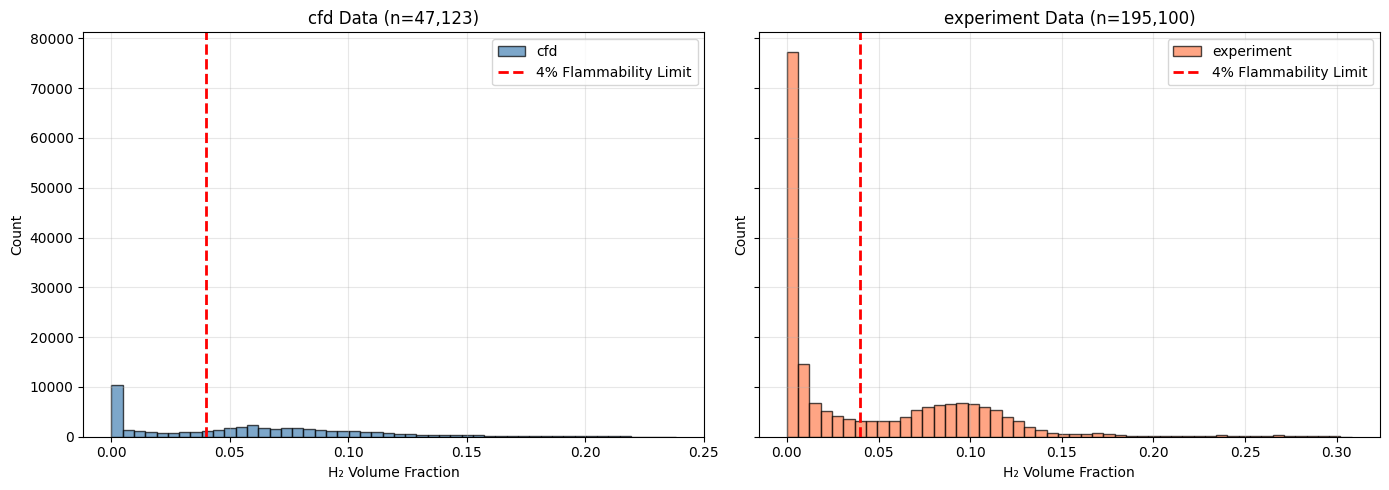

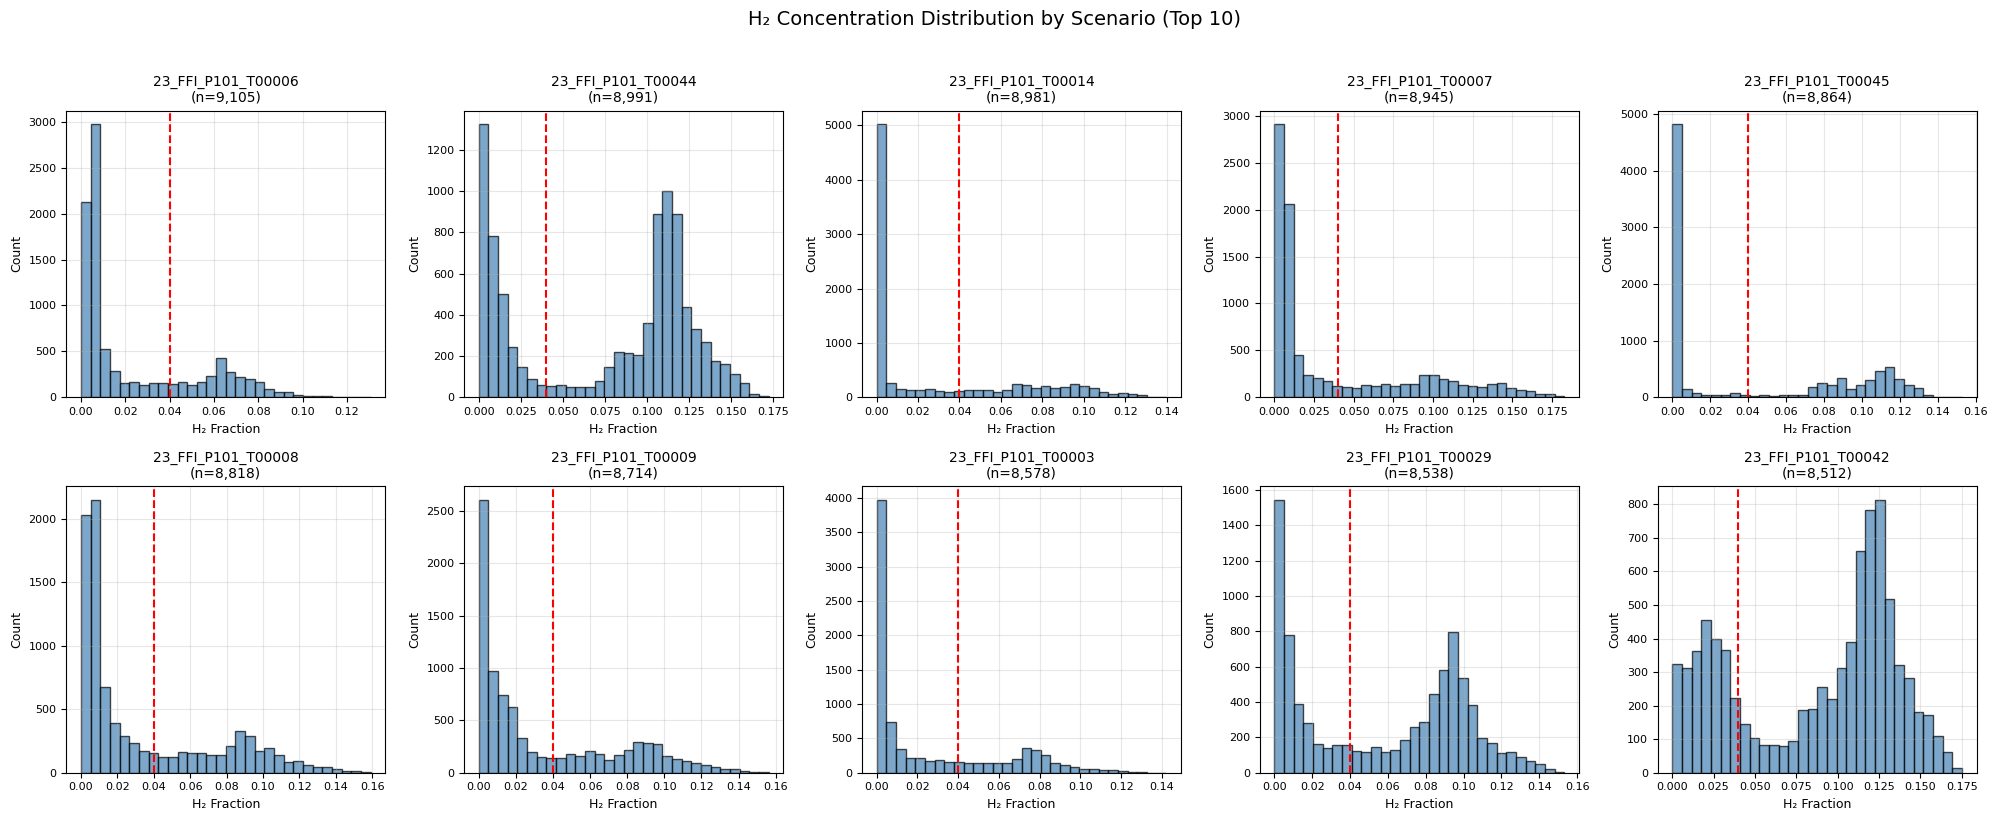

/tmp/ipykernel_1431737/1811486016.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['mass_flow_bin'] = pd.cut(df_clean['mass_flow'], bins=10)


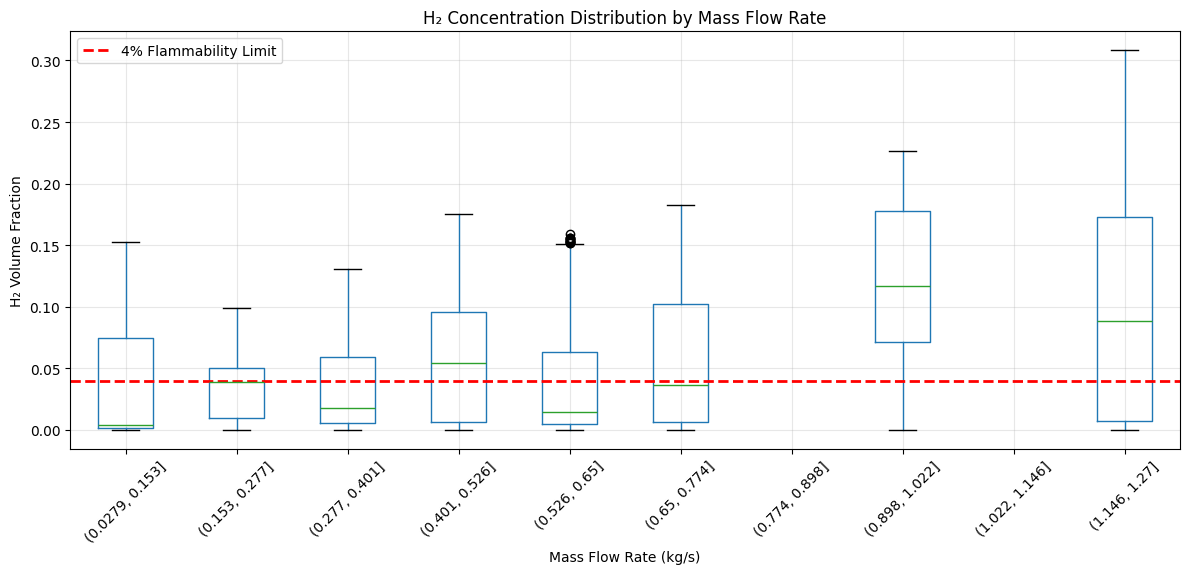

In [18]:
# Load unified data
df = pd.read_csv('data/unified_raw.csv')

# Filter valid concentrations (exclude NaN and extreme outliers)
df_clean = df[df['h2_volume_fraction'].notna() & (df['h2_volume_fraction'] >= 0)]

# =============================================================================
# FIGURE 1: Overall H2 Concentration Distribution
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale histogram
ax1 = axes[0]
ax1.hist(df_clean['h2_volume_fraction'], bins=100, color='steelblue', 
         edgecolor='black', alpha=0.7)
ax1.axvline(x=0.04, color='red', linestyle='--', linewidth=2, 
            label='4% Flammability Limit')
ax1.set_xlabel('H₂ Volume Fraction')
ax1.set_ylabel('Count')
ax1.set_title('H₂ Concentration Distribution (All Data)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log1p transformed histogram (better for skewed data with values near zero)
ax2 = axes[1]
# Apply log1p transformation: log(1 + x) handles zeros safely
h2_transformed = np.log1p(df_clean['h2_volume_fraction'])

ax2.hist(h2_transformed, bins=100, color='coral', 
         edgecolor='black', alpha=0.7)

# Mark the 4% flammability limit in transformed space
flammability_limit_transformed = np.log1p(0.04)
ax2.axvline(x=flammability_limit_transformed, color='red', linestyle='--', 
            linewidth=2, label='4% Flammability Limit')

ax2.set_xlabel('log(1 + H₂ Volume Fraction)')
ax2.set_ylabel('Count')
ax2.set_title('H₂ Concentration Distribution (Log1p Transformed)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Optional: Add secondary x-axis with original values for interpretation
ax2_top = ax2.twiny()
ax2_top.set_xlim(ax2.get_xlim())
# Set tick positions in transformed space and label with original values
original_ticks = [0, 0.01, 0.02, 0.04, 0.08, 0.15, 0.30]
transformed_ticks = np.log1p(original_ticks)
ax2_top.set_xticks(transformed_ticks)
ax2_top.set_xticklabels([f'{x:.2f}' if x < 0.1 else f'{x:.2f}' for x in original_ticks])
ax2_top.set_xlabel('Original H₂ Volume Fraction')

plt.tight_layout()
plt.savefig('h2_concentration_histogram_overall.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("Overall H₂ Concentration Statistics:")
print(f"  Total samples: {len(df_clean):,}")
print(f"  Mean: {df_clean['h2_volume_fraction'].mean():.4f}")
print(f"  Median: {df_clean['h2_volume_fraction'].median():.4f}")
print(f"  Std: {df_clean['h2_volume_fraction'].std():.4f}")
print(f"  Min: {df_clean['h2_volume_fraction'].min():.4f}")
print(f"  Max: {df_clean['h2_volume_fraction'].max():.4f}")
print(f"  Samples above 4% limit: {(df_clean['h2_volume_fraction'] > 0.04).sum():,} "
      f"({100*(df_clean['h2_volume_fraction'] > 0.04).mean():.2f}%)")

# =============================================================================
# FIGURE 2: By Data Source (CFD vs Experiments)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sources = df_clean['source'].unique()
colors = ['steelblue', 'coral']

for ax, source, color in zip(axes, sources, colors):
    data = df_clean[df_clean['source'] == source]['h2_volume_fraction']
    ax.hist(data, bins=50, color=color, edgecolor='black', alpha=0.7, label=source)
    ax.axvline(x=0.04, color='red', linestyle='--', linewidth=2, 
               label='4% Flammability Limit')
    ax.set_xlabel('H₂ Volume Fraction')
    ax.set_ylabel('Count')
    ax.set_title(f'{source} Data (n={len(data):,})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Print stats per source
    print(f"\n{source} Statistics:")
    print(f"  Mean: {data.mean():.4f}, Median: {data.median():.4f}")
    print(f"  Above 4%: {(data > 0.04).sum():,} ({100*(data > 0.04).mean():.2f}%)")

plt.tight_layout()
plt.savefig('h2_concentration_histogram_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 3: By Scenario (Top 10 most common)
# =============================================================================
top_scenarios = df_clean['scenario'].value_counts().head(10).index

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, scenario in enumerate(top_scenarios):
    ax = axes[i]
    data = df_clean[df_clean['scenario'] == scenario]['h2_volume_fraction']
    
    ax.hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(x=0.04, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'{scenario}\n(n={len(data):,})', fontsize=10)
    ax.set_xlabel('H₂ Fraction', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('H₂ Concentration Distribution by Scenario (Top 10)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('h2_concentration_histogram_by_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 4: Box Plot by Mass Flow Rate
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Group by mass flow bins for cleaner visualization
df_clean['mass_flow_bin'] = pd.cut(df_clean['mass_flow'], bins=10)
df_clean.boxplot(column='h2_volume_fraction', by='mass_flow_bin', ax=ax, rot=45)

ax.axhline(y=0.04, color='red', linestyle='--', linewidth=2, 
           label='4% Flammability Limit')
ax.set_xlabel('Mass Flow Rate (kg/s)')
ax.set_ylabel('H₂ Volume Fraction')
ax.set_title('H₂ Concentration Distribution by Mass Flow Rate')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.savefig('h2_concentration_boxplot_by_massflow.png', dpi=150, bbox_inches='tight')
plt.show()